# 改进 ASHMED：方法开发、固定参数与两套数据的验证

原版 ASHMED 的零中心先验及共享尺度在当前两套数据上过于保守。本 notebook 保留它的**四状态贝叶斯收缩、混合先验、local FDR 筛选**，尝试学习非零效应中心、解除两段尺度绑定，并为复合零状态增加正则化。独立插件名为 **ASHMED_Adaptive**，不冒称论文原版或作者官方实现。完整推导见 `docs/ASHMED_ADAPTIVE_METHOD.md`。

**只读取前两个 notebook 已保存的数据，不重新生成。** 两套均有18个条件（线性/已测混杂/二元 × 稀疏/密集 × τ=1.3/1.5/1.9），n=300、m=1000、q=0.05。第一套非零效应有方向及随机波动，第二套有方向且效应固定；这也是本改进的适用范围。

本轮按重复编号分开：1–3测试结构，4–8选择正则强度，9–12确认候选，13–40用于最终比较（**每条件28次**）。最后一组未用于本轮选参数；它们此前已用于原版及对照方法，所以这是保存数据中的内部验证，不能称为独立外部验证。原版 ASHMED、HDMT、MDACT、MLFDR 与前三个 notebook 保留。

In [1]:
find_project_root <- function(start=getwd()) {
  path <- normalizePath(start,winslash="/",mustWork=TRUE)
  for (i in 1:8) {
    if (file.exists(file.path(path,"R/bootstrap.R"))) return(path)
    candidate <- file.path(path,"mlfdr_simulation_lab")
    if (file.exists(file.path(candidate,"R/bootstrap.R"))) return(candidate)
    path <- dirname(path)
  }
  stop("请从工程目录或 notebooks 目录启动。")
}
PROJECT_ROOT <- find_project_root()
source(file.path(PROJECT_ROOT,"R/bootstrap.R"),encoding="UTF-8")
source(file.path(PROJECT_ROOT,"R/ashmed_optimization.R"),encoding="UTF-8")
options(repr.plot.width=10,repr.plot.height=7,repr.plot.res=145,
        repr.matrix.max.rows=90,repr.matrix.max.cols=18)
WORKERS <- 4L
campaign <- optimization_directory(PROJECT_ROOT)
lock <- readRDS(file.path(campaign,"locked_method.rds"))
SELECTED_OPTIONS <- lock$selection$options
registry <- load_method_registry(PROJECT_ROOT)
stopifnot(identical(method_fingerprint(registry$ASHMED_Adaptive,PROJECT_ROOT),lock$selection$fingerprint))
canonical <- environment(registry$ASHMED_Adaptive$run)$adaptive_options(SELECTED_OPTIONS)
canonical$base <- NULL
cat("选定方案：",lock$selection$arm,"；q=0.05；最终重复13:40\n")
print(canonical)
inputs <- optimization_inputs(PROJECT_ROOT)
IRdisplay::display(do.call(rbind,lapply(names(inputs),function(name) {
  x <- inputs[[name]]
  data.frame(dataset=name,data_id=x$manifest$data_id,saved_datasets=nrow(x$manifest$design),
    final_datasets=18*28,n=x$config$n,m=x$config$m,q=x$config$q)
})))

选定方案： null10 ；q=0.05；最终重复13:40


$J
[1] 6

$r_min
[1] 0.25

$r_max
[1] 8

$correlations
[1] 0

$grid_mode
[1] "rectangular"

$learn_location
[1] TRUE

$zero_anchor
[1] FALSE

$include_atom
[1] TRUE

$minimum_location_se
[1] 0.5

$null_pseudocount
[1] 10

$relative_tolerance
[1] 1e-08

$kkt_tolerance
[1] 1e-04

$max_iter
[1] 5000

$accelerate
[1] TRUE

$location_max_iter
[1] 1500

$location_tolerance
[1] 1e-06



dataset,data_id,saved_datasets,final_datasets,n,m,q
<chr>,<chr>,<int>,<dbl>,<int>,<int>,<dbl>
paper_adjusted,data_f87521c2b4eb,720,504,300,1000,0.05
teaching_fixed,data_c054ed713a76,720,504,300,1000,0.05


## 方法改动与原因

设 $\hat\theta_i=(\hat\alpha_i,\hat\beta_i)^T\mid\theta_i\sim N_2(\theta_i,S_i)$，继续使用原 OLS/GLM 摘要与标准误。四状态 H00/H10/H01/H11 的定义不变，只有 H11 是真中介。

1. **学习方向与位置。** 在每个边际拟合“精确零点质量 + 自由均值正态”经验贝叶斯模型。用四个确定起点，按观测似然选结果，从摘要估计非零均值 $\mu_\alpha,\mu_\beta$；不读取真值。
2. **允许独立尺度及固定效应。** 围绕学习的均值放置6个正方差尺度和1个非零点质量，H11用两个尺度的笛卡尔积。典型模型共有 $1+7+7+49=64$ 成分，允许两段效应的离散程度不同。
3. **避免近零替代成分混淆。** 开发结果显示，保留大量零中心替代成分会抢走精确零状态的权重，导致 FDR 膨胀。选定版本只用有方向的非零中心替代字典。如果任一学习中心距零不足0.5倍中位标准误，则退回未修改的原版 ASHMED；不把近零点质量称作非零。
4. **对复合零状态正则化。** 最大化

\[
\sum_i\log\sum_kw_k f_{ik}+\frac{\lambda}{3}(\log\pi_{00}+\log\pi_{10}+\log\pi_{01}),
\quad \pi_s=\sum_{k:s(k)=s}w_k.
\]

这是状态权重的 Dirichlet 型 MAP 目标；EM 更新增加三个零状态的伪计数，保留非负、和为1的权重。固定字典的目标凹，优化同时检查目标单调性及 KKT gap。中心估计本身不保证全局最优。$\lambda$ 只在开发重复中选择，**q 始终0.05**，没有通过降低阈值或修改 DGP 调结果。

该思路参考 [Stephens (2017) 方法补充材料](https://stephenslab.uchicago.edu/assets/papers/Stephens2017-supplement.pdf) 中学习非零中心、通过混合比例惩罚稳定零成分的讨论；这里将其改为中介四状态模型，具体推导及实现差异见方法文档。

## 完整开发记录：失败方案也显示

结构测试用每条件3次；随后只对更可识别的非零中心字典测试 λ=0/10/30/90，每条件5次。下表“平均”是18个固定条件等权平均；最大FDR是最差条件均值，不能用整体平均掩盖坏条件。

事先记录的**开发筛选门槛**为两套数据分别满足：整体平均 FDR≤0.06、最差条件 FDR≤0.15、Power高于原版、无方法错误。门槛仅用于少量开发重复筛选，不是0.05 FDR控制定理。合格方案中选平均Power最高者，再用9–12确认；确认失败时脚本会停止。最终28次比较不再据此改参数。

结构测试：


arm,dataset,mean_FDR,max_FDR,mean_power,original_power,gain,errors,warnings,passes
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<lgl>
zero_rect,paper_adjusted,0.37943008,0.5612923,0.8819348,0.4463051,0.4356297,0,0,FALSE
zero_rect,teaching_fixed,0.34870127,0.5976439,0.8587963,0.3825000,0.4762963,0,0,FALSE
shifted_same,paper_adjusted,0.12401136,0.4198780,0.7295417,0.4463051,0.2832365,0,0,FALSE
shifted_same,teaching_fixed,0.13668513,0.5431275,0.7778704,0.3825000,0.3953704,0,0,FALSE
shifted_rect,paper_adjusted,0.23596773,0.5174914,0.8082980,0.4463051,0.3619928,0,0,FALSE
shifted_rect,teaching_fixed,0.19189867,0.6050061,0.7852778,0.3825000,0.4027778,0,0,FALSE
shifted_rect_no_anchor,paper_adjusted,0.05955445,0.2638889,0.7649137,0.4463051,0.3186085,0,0,FALSE
shifted_rect_no_anchor,teaching_fixed,0.06630387,0.1917989,0.7358333,0.3825000,0.3533333,0,0,FALSE


正则强度开发：


arm,dataset,mean_FDR,max_FDR,mean_power,original_power,gain,errors,warnings,passes
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<lgl>
null0,paper_adjusted,0.06710800,0.17727255,0.7355231,0.4317519,0.3037712,0,0,FALSE
null0,teaching_fixed,0.05233052,0.11464052,0.7298333,0.4081111,0.3217222,0,0,TRUE
null10,paper_adjusted,0.05453472,0.10650794,0.7164996,0.4317519,0.2847477,0,0,TRUE
null10,teaching_fixed,0.04766417,0.10586081,0.7154444,0.4081111,0.3073333,0,0,TRUE
null30,paper_adjusted,0.04513345,0.09843137,0.6929099,0.4317519,0.2611581,0,0,TRUE
null30,teaching_fixed,0.04515797,0.08787879,0.6962778,0.4081111,0.2881667,0,0,TRUE
null90,paper_adjusted,0.04031078,0.10138889,0.6484251,0.4317519,0.2166733,0,0,TRUE
null90,teaching_fixed,0.03432370,0.05818182,0.6562778,0.4081111,0.2481667,0,0,TRUE


独立于开发重复的候选确认：


arm,dataset,mean_FDR,max_FDR,mean_power,original_power,gain,errors,warnings,passes
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<lgl>
null10,paper_adjusted,0.04408301,0.08173077,0.7173639,0.4495406,0.2678233,0,0,TRUE
null10,teaching_fixed,0.04375971,0.07210452,0.7037500,0.3973611,0.3063889,0,0,TRUE


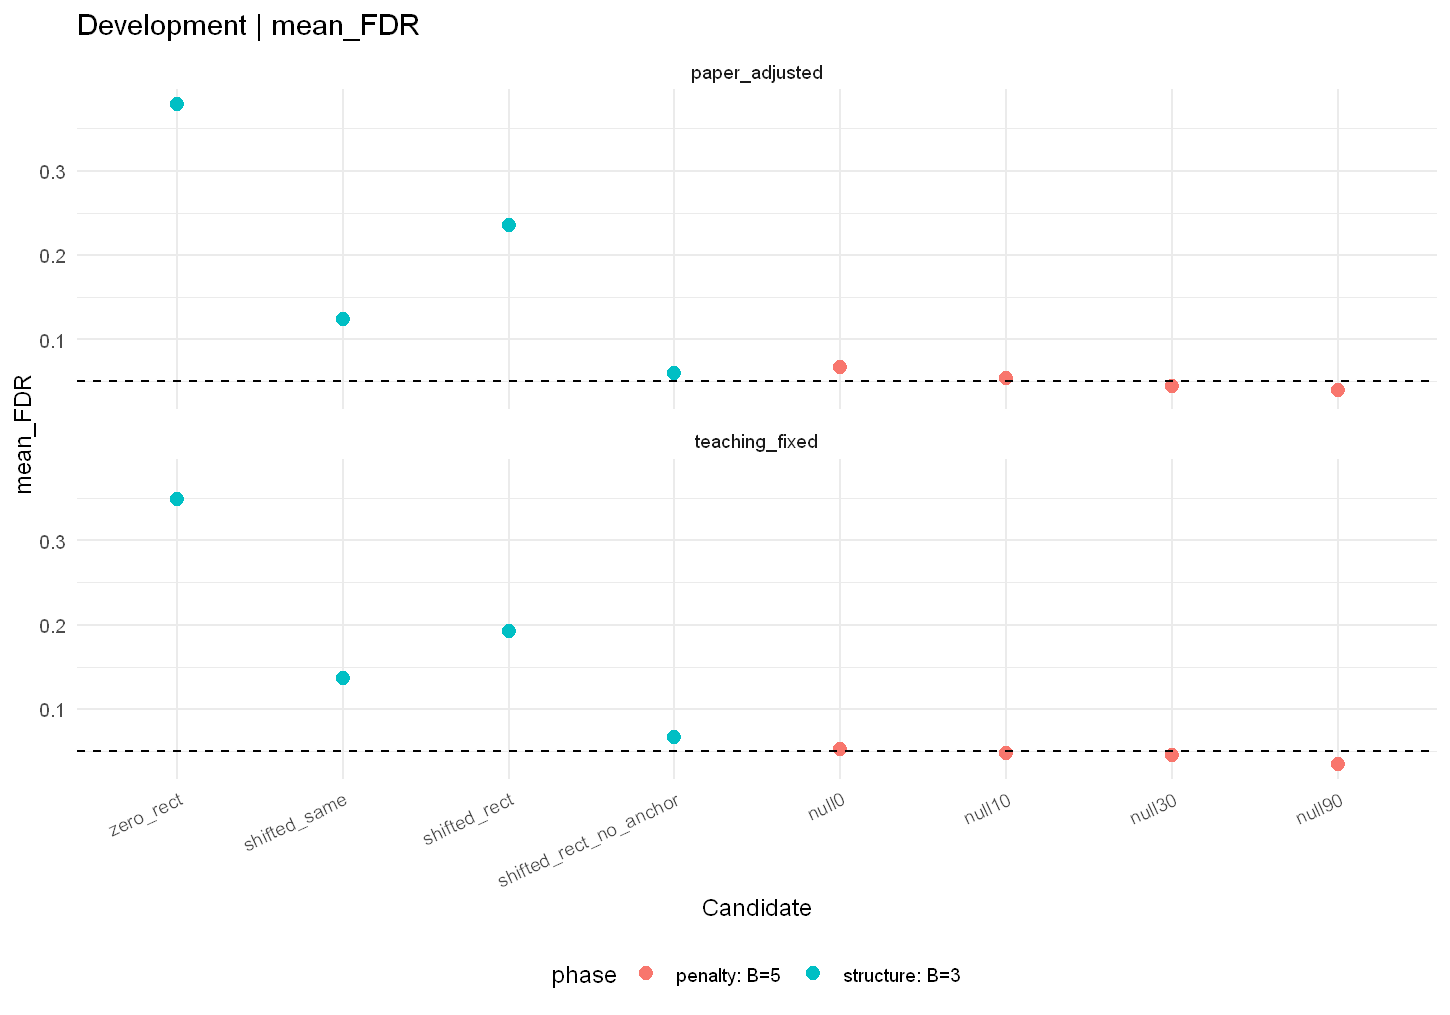

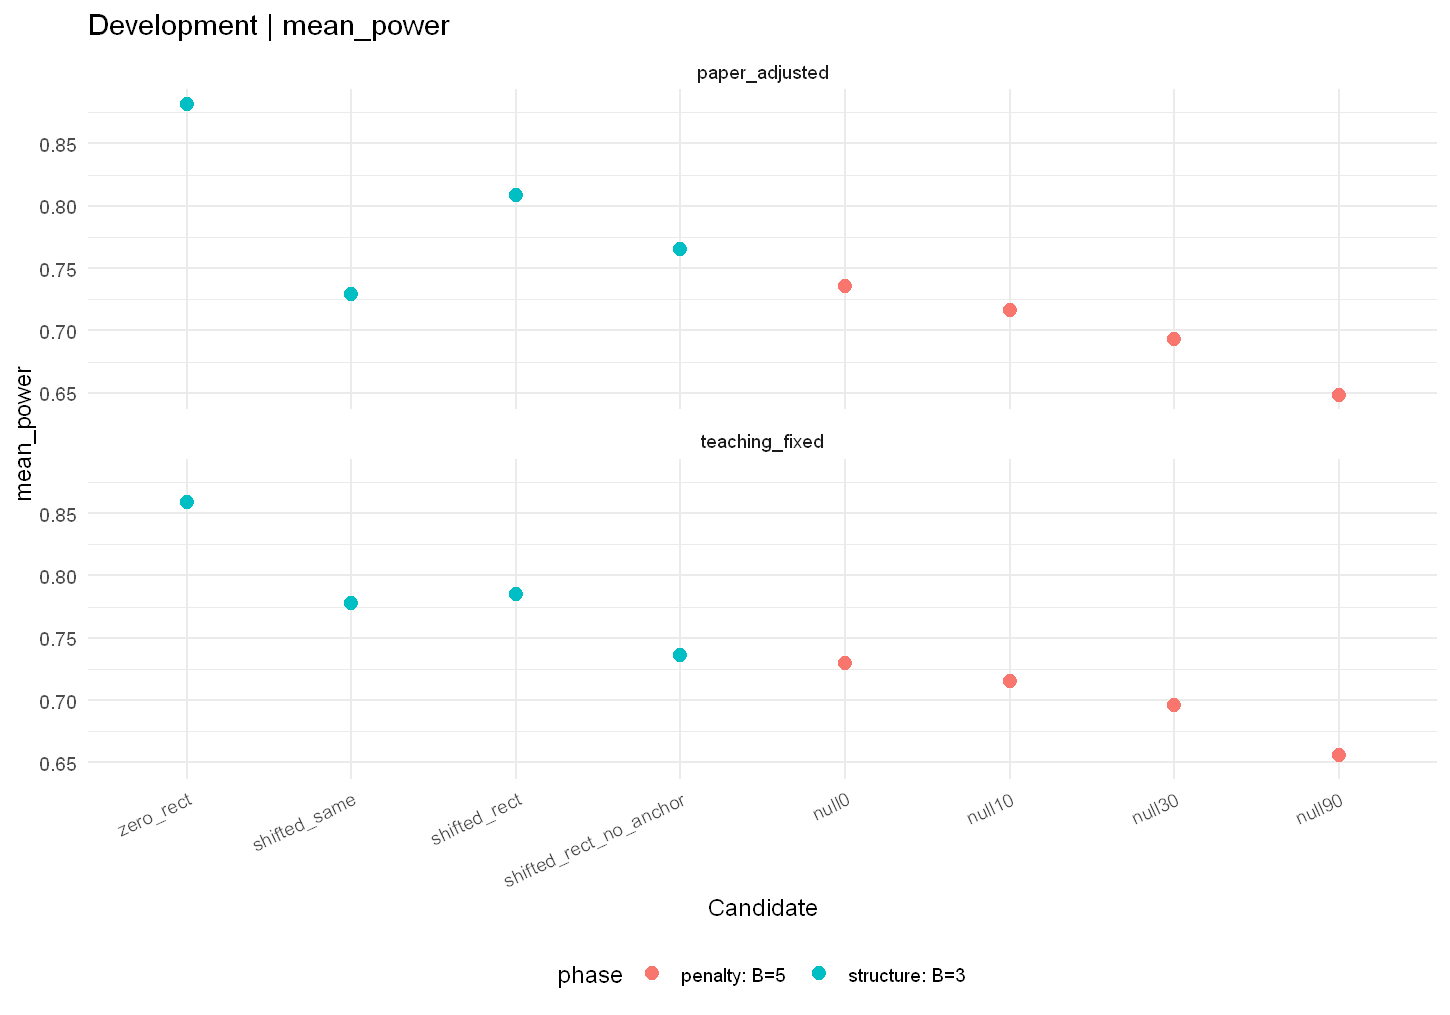

In [2]:
structure_scores <- read.csv(file.path(campaign,"structure_scores.csv"),stringsAsFactors=FALSE)
development_scores <- read.csv(file.path(campaign,"development_scores.csv"),stringsAsFactors=FALSE)
confirmation_scores <- read.csv(file.path(campaign,"confirmation_scores.csv"),stringsAsFactors=FALSE)
cat("结构测试：\n"); IRdisplay::display(structure_scores)
cat("正则强度开发：\n"); IRdisplay::display(development_scores)
cat("独立于开发重复的候选确认：\n"); IRdisplay::display(confirmation_scores)
stopifnot(all(confirmation_scores$passes))
dev <- rbind(transform(structure_scores,phase="structure: B=3"),
             transform(development_scores,phase="penalty: B=5"))
dev$arm <- factor(dev$arm,levels=unique(dev$arm))
for (metric in c("mean_FDR","mean_power")) {
  g <- ggplot2::ggplot(dev,ggplot2::aes(arm,.data[[metric]],color=phase))+
    ggplot2::geom_point(size=3)+ggplot2::facet_wrap(~dataset,ncol=1)+
    ggplot2::theme_minimal(base_size=12)+
    ggplot2::theme(axis.text.x=ggplot2::element_text(angle=25,hjust=1),legend.position="bottom")+
    ggplot2::labs(x="Candidate",y=metric,title=paste("Development |",metric))
  if (metric=="mean_FDR") g <- g+ggplot2::geom_hline(yintercept=.05,linetype=2)
  print(g)
  ggplot2::ggsave(file.path(campaign,paste0("development_",metric,".png")),g,
                   width=10,height=7,dpi=160,bg="white")
}

## 固定参数后的最终四方法比较

读取13–40次保存数据，仅运行 ASHMED_Adaptive；HDMT、MDACT、MLFDR 及原版 ASHMED 从原实验提取**完全相同 case_id 的结果**。逐项核对原指标没有改变，检查720份原始文件/套的 MD5，另外检查原插件、三个 notebook、manifest 和原结果的保护指纹。

指标沿用原工程：每次 FDP=V/max(R,1)，Power=S/A；经验FDR是28次FDP平均，MCSE=SD/√28，阴影是同样的近似95%蒙特卡洛均值区间。并未改为合并V/合并R。整体表是18条件等权均值，区间按重复编号的平均块计算；条件图和表才是判断校准的主要依据。

In [3]:
suite <- run_final_adaptive_comparison(PROJECT_ROOT,WORKERS)
for (name in names(suite)) {
  x <- suite[[name]]
  cat("\n",name,"：",x$directory,"\n")
  IRdisplay::display(x$macro)
  IRdisplay::display(x$data_audit)
  IRdisplay::display(x$reference_audit)
}

Analysed 12/504 saved datasets; method errors: 0



Analysed 24/504 saved datasets; method errors: 0



Analysed 36/504 saved datasets; method errors: 0



Analysed 48/504 saved datasets; method errors: 0



Analysed 60/504 saved datasets; method errors: 0



...

metric,n_compared,max_difference,unchanged
<chr>,<int>,<dbl>,<lgl>
discoveries,2016,0,TRUE
false_discoveries,2016,0,TRUE
true_discoveries,2016,0,TRUE
alternatives,2016,0,TRUE
FDP,2016,0,TRUE
power,2016,0,TRUE


method,conditions,repetitions,FDR_mean,FDR_mcse,FDR_lo,FDR_hi,power_mean,power_mcse,power_lo,power_hi
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HDMT,18,28,0.03529233,0.002578863,0.03000094,0.04058372,0.4817857,0.004944525,0.4716404,0.4919310
MDACT,18,28,0.04379319,0.003523819,0.03656291,0.05102347,0.5187302,0.005721140,0.5069913,0.5304690
MLFDR,18,28,0.04857044,0.001907756,0.04465605,0.05248484,0.7252877,0.005001173,0.7150261,0.7355493
ASHMED,18,28,0.02038785,0.001968013,0.01634982,0.02442587,0.3970437,0.004216734,0.3883916,0.4056957
ASHMED_Adaptive,18,28,0.04656959,0.002236911,0.04197983,0.05115935,0.7148413,0.005176979,0.7042190,0.7254636


dataset,saved_datasets,checksum_matches,manifest_unchanged
<chr>,<int>,<int>,<lgl>
teaching_fixed,720,720,TRUE


metric,n_compared,max_difference,unchanged
<chr>,<int>,<dbl>,<lgl>
discoveries,2016,0,TRUE
false_discoveries,2016,0,TRUE
true_discoveries,2016,0,TRUE
alternatives,2016,0,TRUE
FDP,2016,0,TRUE
power,2016,0,TRUE



 paper_adjusted ： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/results/ashmed_optimization_20261005/validation_paper_adjusted 

 teaching_fixed ： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/results/ashmed_optimization_20261005/validation_teaching_fixed 


## 第一套：论文模型增强信号

紫色为改进版，蓝/绿/红为HDMT/MDACT/MLFDR。左列FDR、右列Power，上排稀疏、下排密集；虚线q=0.05。

### 连续线性结局

,mixture,tau,method,n_success,n_error,FDR_mean,FDR_mcse,FDR_lo,FDR_hi,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
62,dense,1.3,ASHMED_Adaptive,28,0,0.0431,0.0033,0.0364,0.0498,0.6966,0.0167
63,dense,1.3,HDMT,28,0,0.0316,0.0043,0.0228,0.0404,0.3731,0.0230
64,dense,1.3,MDACT,28,0,0.0390,0.0041,0.0305,0.0474,0.4361,0.0211
65,dense,1.3,MLFDR,28,0,0.0430,0.0033,0.0363,0.0498,0.6982,0.0170
67,dense,1.5,ASHMED_Adaptive,28,0,0.0559,0.0033,0.0490,0.0627,0.8112,0.0111
68,dense,1.5,HDMT,28,0,0.0358,0.0030,0.0297,0.0419,0.5581,0.0225
69,dense,1.5,MDACT,28,0,0.0450,0.0027,0.0394,0.0505,0.6011,0.0192
70,dense,1.5,MLFDR,28,0,0.0563,0.0037,0.0487,0.0638,0.8142,0.0111
72,dense,1.9,ASHMED_Adaptive,28,0,0.0462,0.0024,0.0413,0.0511,0.9468,0.0078


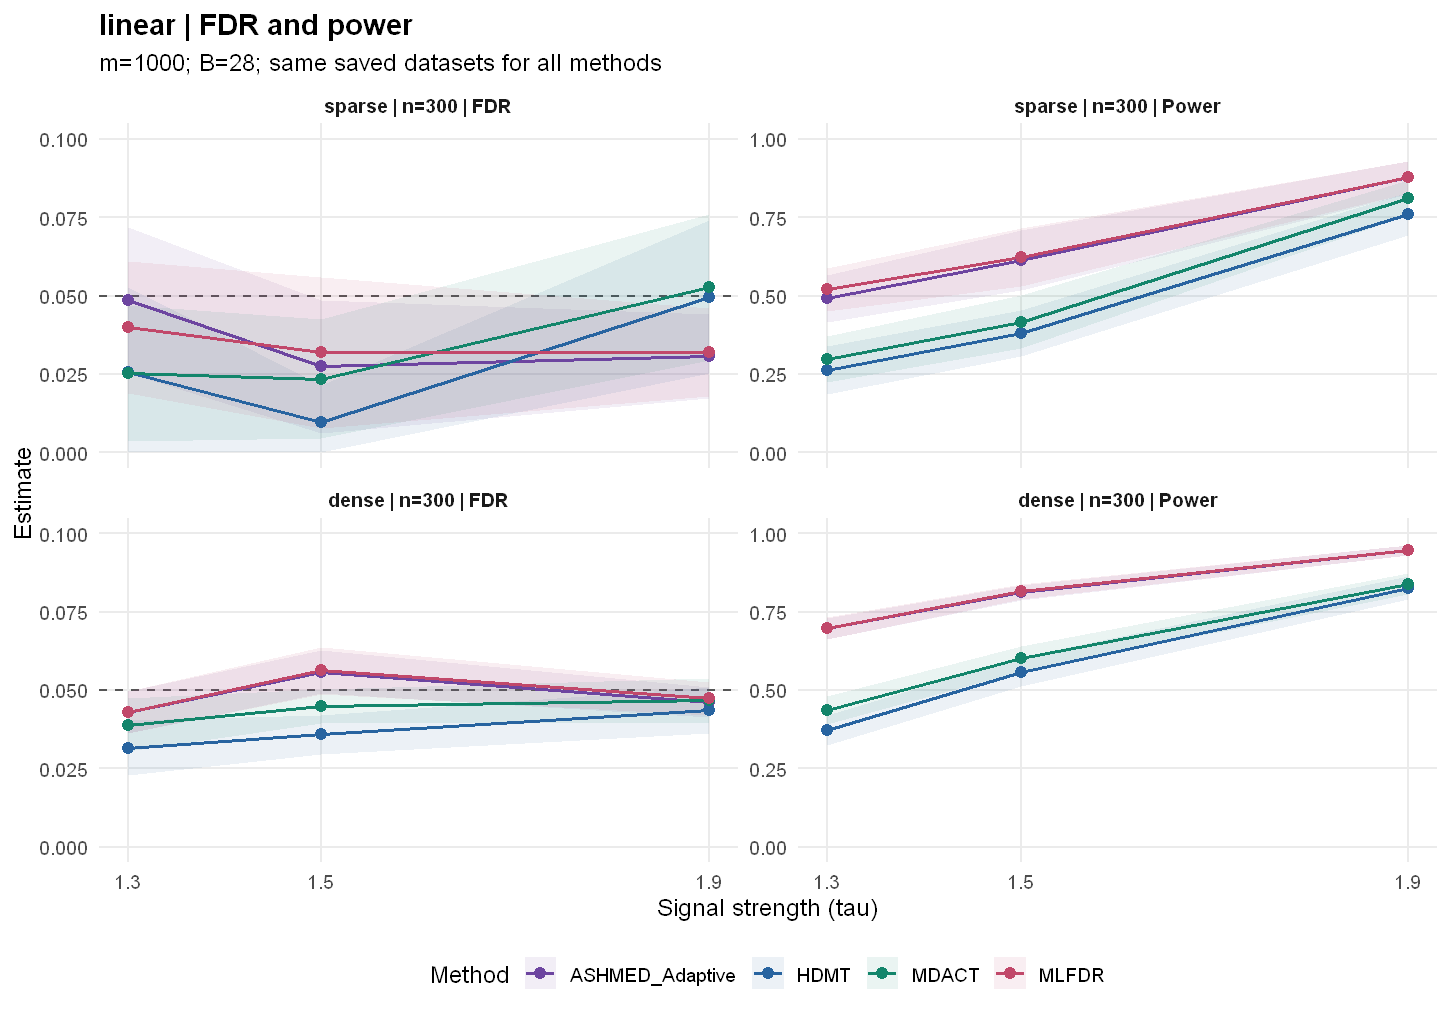

In [4]:
x <- suite[["paper_adjusted"]]
print(plot_adaptive_comparison(x$main,"linear"))
tab <- x$main[x$main$scenario=="linear",c("mixture","tau","method","n_success","n_error",
  "FDR_mean","FDR_mcse","FDR_lo","FDR_hi","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1)); tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

### 已测混杂并调整Z

,mixture,tau,method,n_success,n_error,FDR_mean,FDR_mcse,FDR_lo,FDR_hi,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
32,dense,1.3,ASHMED_Adaptive,28,0,0.0544,0.0029,0.0483,0.0604,0.7030,0.0141
33,dense,1.3,HDMT,28,0,0.0345,0.0040,0.0263,0.0427,0.3939,0.0229
34,dense,1.3,MDACT,28,0,0.0437,0.0041,0.0353,0.0521,0.4643,0.0198
35,dense,1.3,MLFDR,28,0,0.0549,0.0031,0.0485,0.0613,0.7065,0.0140
37,dense,1.5,ASHMED_Adaptive,28,0,0.0452,0.0029,0.0393,0.0511,0.8304,0.0084
38,dense,1.5,HDMT,28,0,0.0319,0.0039,0.0240,0.0399,0.5732,0.0161
39,dense,1.5,MDACT,28,0,0.0386,0.0041,0.0301,0.0471,0.6166,0.0156
40,dense,1.5,MLFDR,28,0,0.0461,0.0030,0.0399,0.0522,0.8324,0.0084
42,dense,1.9,ASHMED_Adaptive,28,0,0.0505,0.0022,0.0460,0.0550,0.9426,0.0080


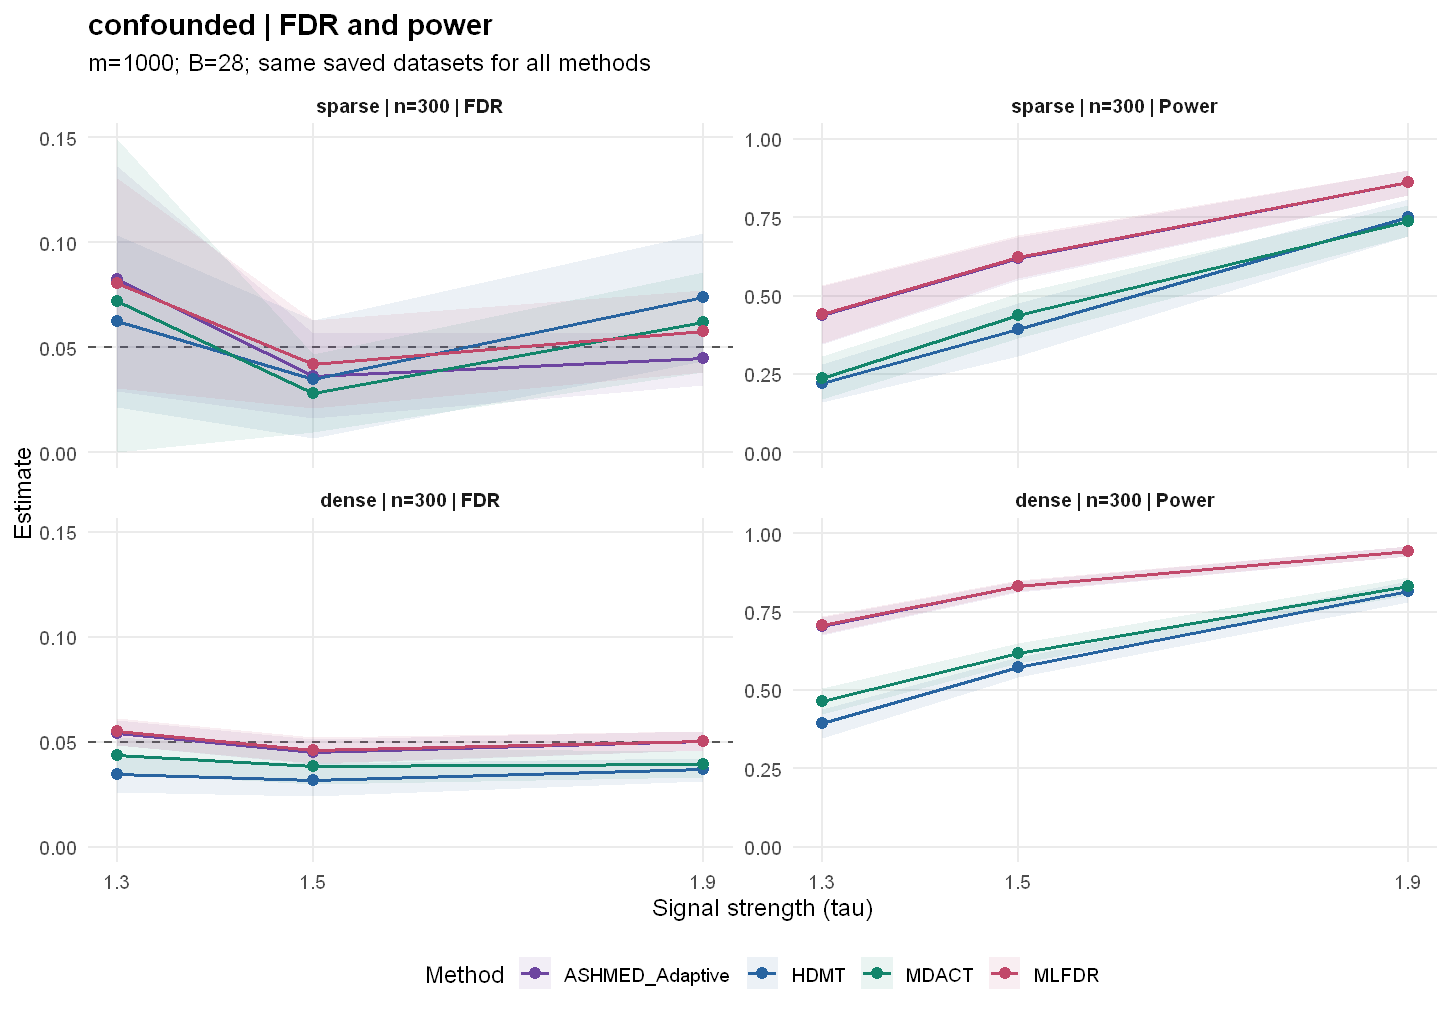

In [5]:
x <- suite[["paper_adjusted"]]
print(plot_adaptive_comparison(x$main,"confounded"))
tab <- x$main[x$main$scenario=="confounded",c("mixture","tau","method","n_success","n_error",
  "FDR_mean","FDR_mcse","FDR_lo","FDR_hi","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1)); tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

### 二元结局：GLM正态摘要扩展

,mixture,tau,method,n_success,n_error,FDR_mean,FDR_mcse,FDR_lo,FDR_hi,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,dense,1.3,ASHMED_Adaptive,28,0,0.0437,0.0041,0.0353,0.0520,0.6366,0.0226
3,dense,1.3,HDMT,28,0,0.0290,0.0053,0.0181,0.0398,0.3472,0.0223
4,dense,1.3,MDACT,28,0,0.0427,0.0047,0.0329,0.0524,0.4042,0.0213
5,dense,1.3,MLFDR,28,0,0.0445,0.0041,0.0360,0.0530,0.6402,0.0226
7,dense,1.5,ASHMED_Adaptive,28,0,0.0454,0.0033,0.0385,0.0523,0.8240,0.0105
8,dense,1.5,HDMT,28,0,0.0318,0.0036,0.0243,0.0392,0.5796,0.0162
9,dense,1.5,MDACT,28,0,0.0393,0.0041,0.0310,0.0476,0.6275,0.0135
10,dense,1.5,MLFDR,28,0,0.0447,0.0030,0.0386,0.0507,0.8284,0.0104
12,dense,1.9,ASHMED_Adaptive,28,0,0.0473,0.0031,0.0409,0.0537,0.9579,0.0053


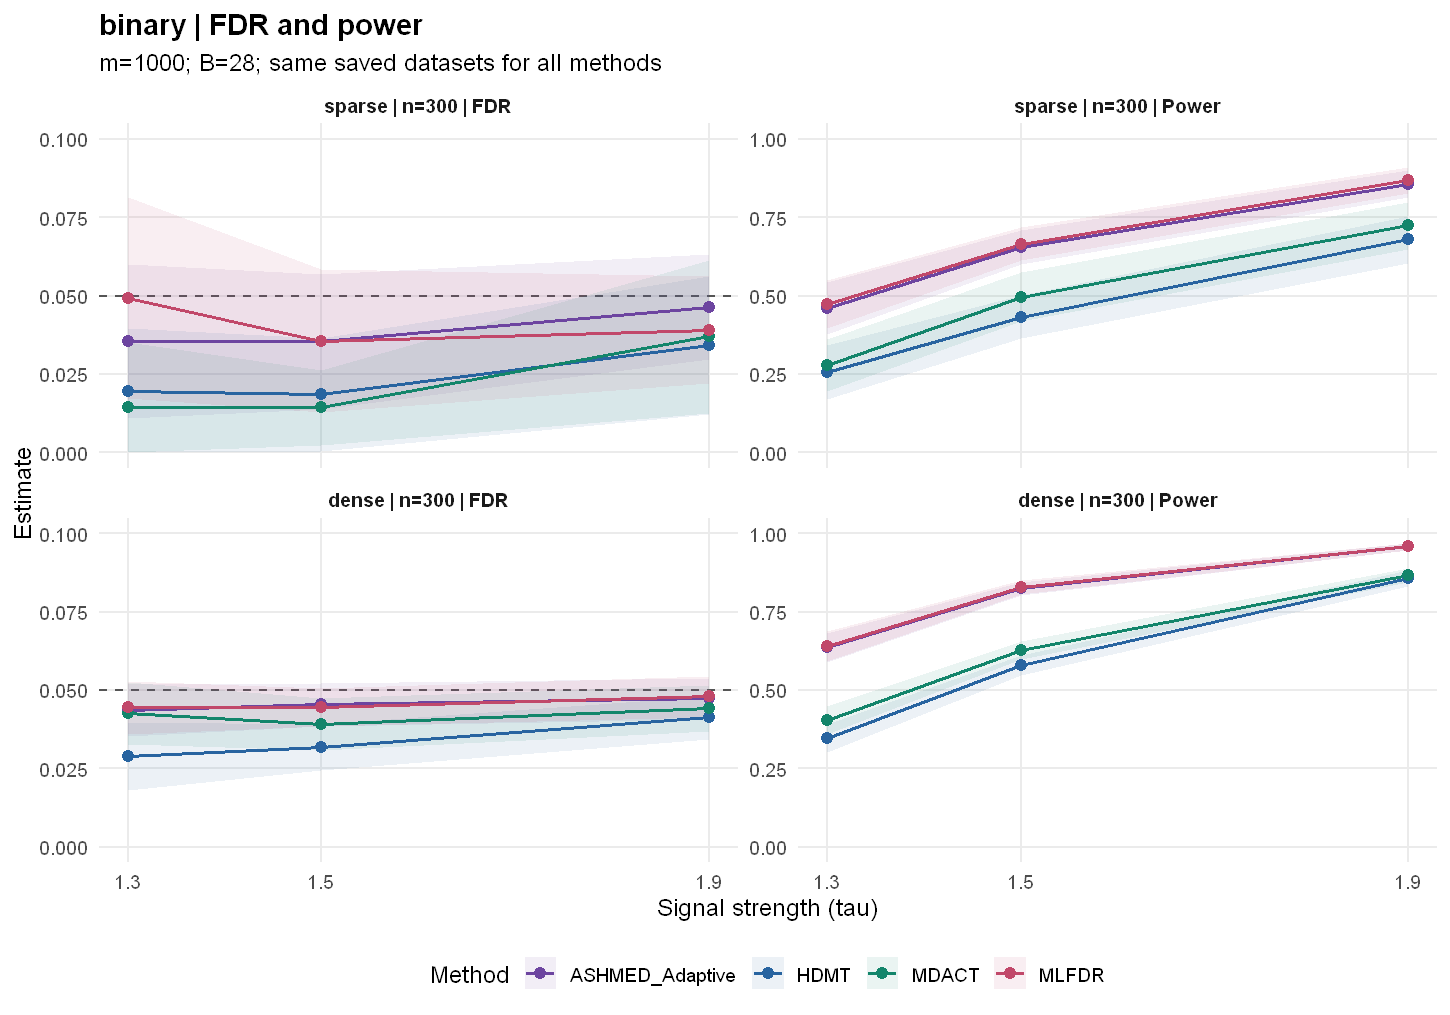

In [6]:
x <- suite[["paper_adjusted"]]
print(plot_adaptive_comparison(x$main,"binary"))
tab <- x$main[x$main$scenario=="binary",c("mixture","tau","method","n_success","n_error",
  "FDR_mean","FDR_mcse","FDR_lo","FDR_hi","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1)); tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

## 第二套：固定效应教学数据

紫色为改进版，蓝/绿/红为HDMT/MDACT/MLFDR。左列FDR、右列Power，上排稀疏、下排密集；虚线q=0.05。

### 连续线性结局

,mixture,tau,method,n_success,n_error,FDR_mean,FDR_mcse,FDR_lo,FDR_hi,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
62,dense,1.3,ASHMED_Adaptive,28,0,0.0452,0.0034,0.0382,0.0522,0.6480,0.0078
63,dense,1.3,HDMT,28,0,0.0283,0.0032,0.0217,0.0349,0.3148,0.0106
64,dense,1.3,MDACT,28,0,0.0374,0.0036,0.0301,0.0448,0.3738,0.0116
65,dense,1.3,MLFDR,28,0,0.0457,0.0035,0.0385,0.0528,0.6516,0.0078
67,dense,1.5,ASHMED_Adaptive,28,0,0.0520,0.0029,0.0461,0.0578,0.7984,0.0093
68,dense,1.5,HDMT,28,0,0.0362,0.0037,0.0286,0.0439,0.5289,0.0135
69,dense,1.5,MDACT,28,0,0.0416,0.0037,0.0339,0.0493,0.5780,0.0132
70,dense,1.5,MLFDR,28,0,0.0517,0.0029,0.0458,0.0577,0.8020,0.0090
72,dense,1.9,ASHMED_Adaptive,28,0,0.0487,0.0025,0.0436,0.0539,0.9486,0.0033


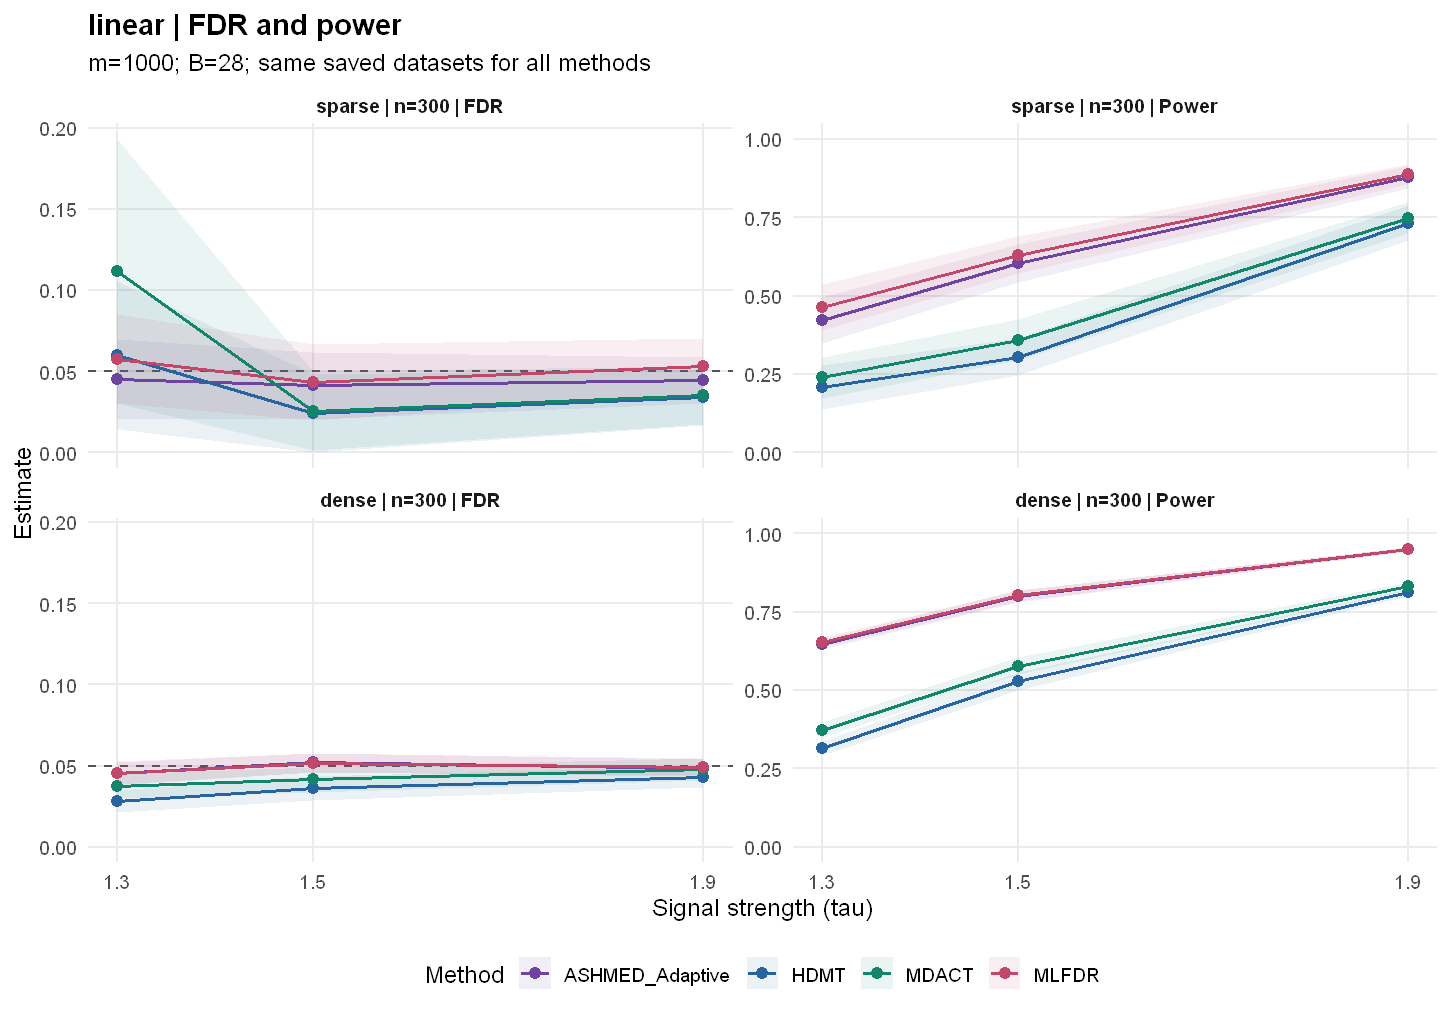

In [7]:
x <- suite[["teaching_fixed"]]
print(plot_adaptive_comparison(x$main,"linear"))
tab <- x$main[x$main$scenario=="linear",c("mixture","tau","method","n_success","n_error",
  "FDR_mean","FDR_mcse","FDR_lo","FDR_hi","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1)); tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

### 已测混杂并调整Z

,mixture,tau,method,n_success,n_error,FDR_mean,FDR_mcse,FDR_lo,FDR_hi,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
32,dense,1.3,ASHMED_Adaptive,28,0,0.0460,0.0029,0.0400,0.0520,0.6589,0.0079
33,dense,1.3,HDMT,28,0,0.0318,0.0035,0.0245,0.0391,0.3211,0.0096
34,dense,1.3,MDACT,28,0,0.0422,0.0042,0.0336,0.0508,0.3843,0.0100
35,dense,1.3,MLFDR,28,0,0.0471,0.0032,0.0406,0.0536,0.6643,0.0080
37,dense,1.5,ASHMED_Adaptive,28,0,0.0494,0.0032,0.0429,0.0559,0.8055,0.0070
38,dense,1.5,HDMT,28,0,0.0355,0.0045,0.0262,0.0449,0.5116,0.0087
39,dense,1.5,MDACT,28,0,0.0428,0.0046,0.0333,0.0523,0.5650,0.0094
40,dense,1.5,MLFDR,28,0,0.0505,0.0033,0.0437,0.0573,0.8093,0.0069
42,dense,1.9,ASHMED_Adaptive,28,0,0.0518,0.0027,0.0462,0.0573,0.9439,0.0036


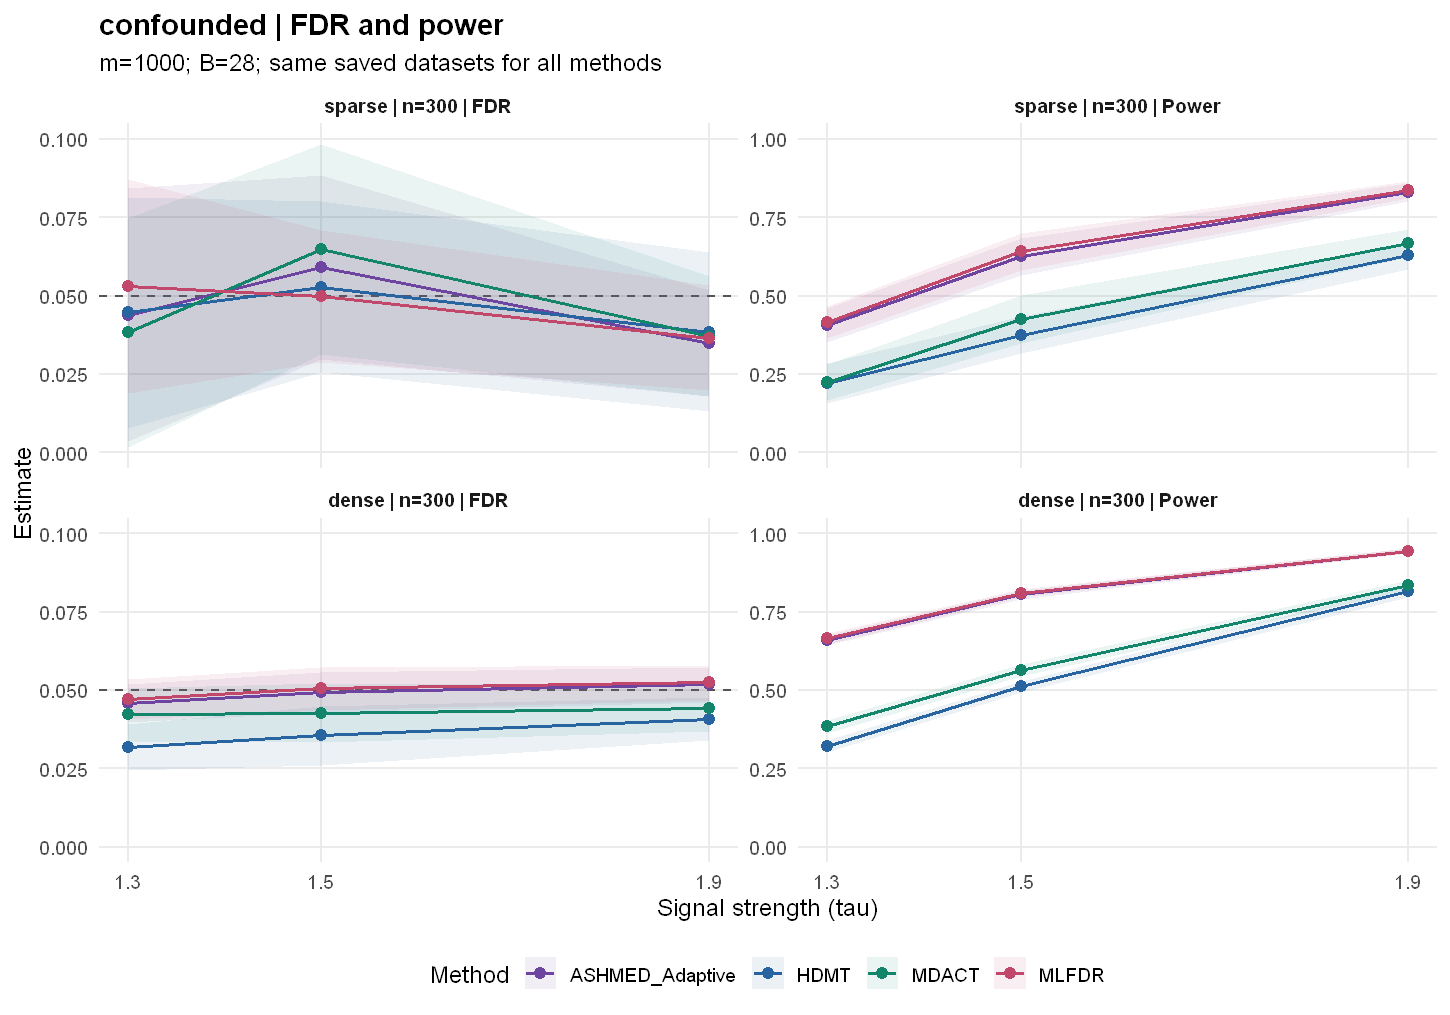

In [8]:
x <- suite[["teaching_fixed"]]
print(plot_adaptive_comparison(x$main,"confounded"))
tab <- x$main[x$main$scenario=="confounded",c("mixture","tau","method","n_success","n_error",
  "FDR_mean","FDR_mcse","FDR_lo","FDR_hi","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1)); tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

### 二元结局：GLM正态摘要扩展

,mixture,tau,method,n_success,n_error,FDR_mean,FDR_mcse,FDR_lo,FDR_hi,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,dense,1.3,ASHMED_Adaptive,28,0,0.0484,0.0026,0.0430,0.0538,0.6488,0.0074
3,dense,1.3,HDMT,28,0,0.0272,0.0043,0.0183,0.0361,0.3384,0.0104
4,dense,1.3,MDACT,28,0,0.0381,0.0040,0.0299,0.0463,0.3950,0.0093
5,dense,1.3,MLFDR,28,0,0.0493,0.0026,0.0439,0.0547,0.6536,0.0074
7,dense,1.5,ASHMED_Adaptive,28,0,0.0456,0.0033,0.0387,0.0525,0.7954,0.0069
8,dense,1.5,HDMT,28,0,0.0289,0.0030,0.0227,0.0352,0.5100,0.0122
9,dense,1.5,MDACT,28,0,0.0369,0.0032,0.0303,0.0435,0.5643,0.0126
10,dense,1.5,MLFDR,28,0,0.0461,0.0033,0.0394,0.0527,0.7984,0.0070
12,dense,1.9,ASHMED_Adaptive,28,0,0.0453,0.0025,0.0402,0.0504,0.9464,0.0042


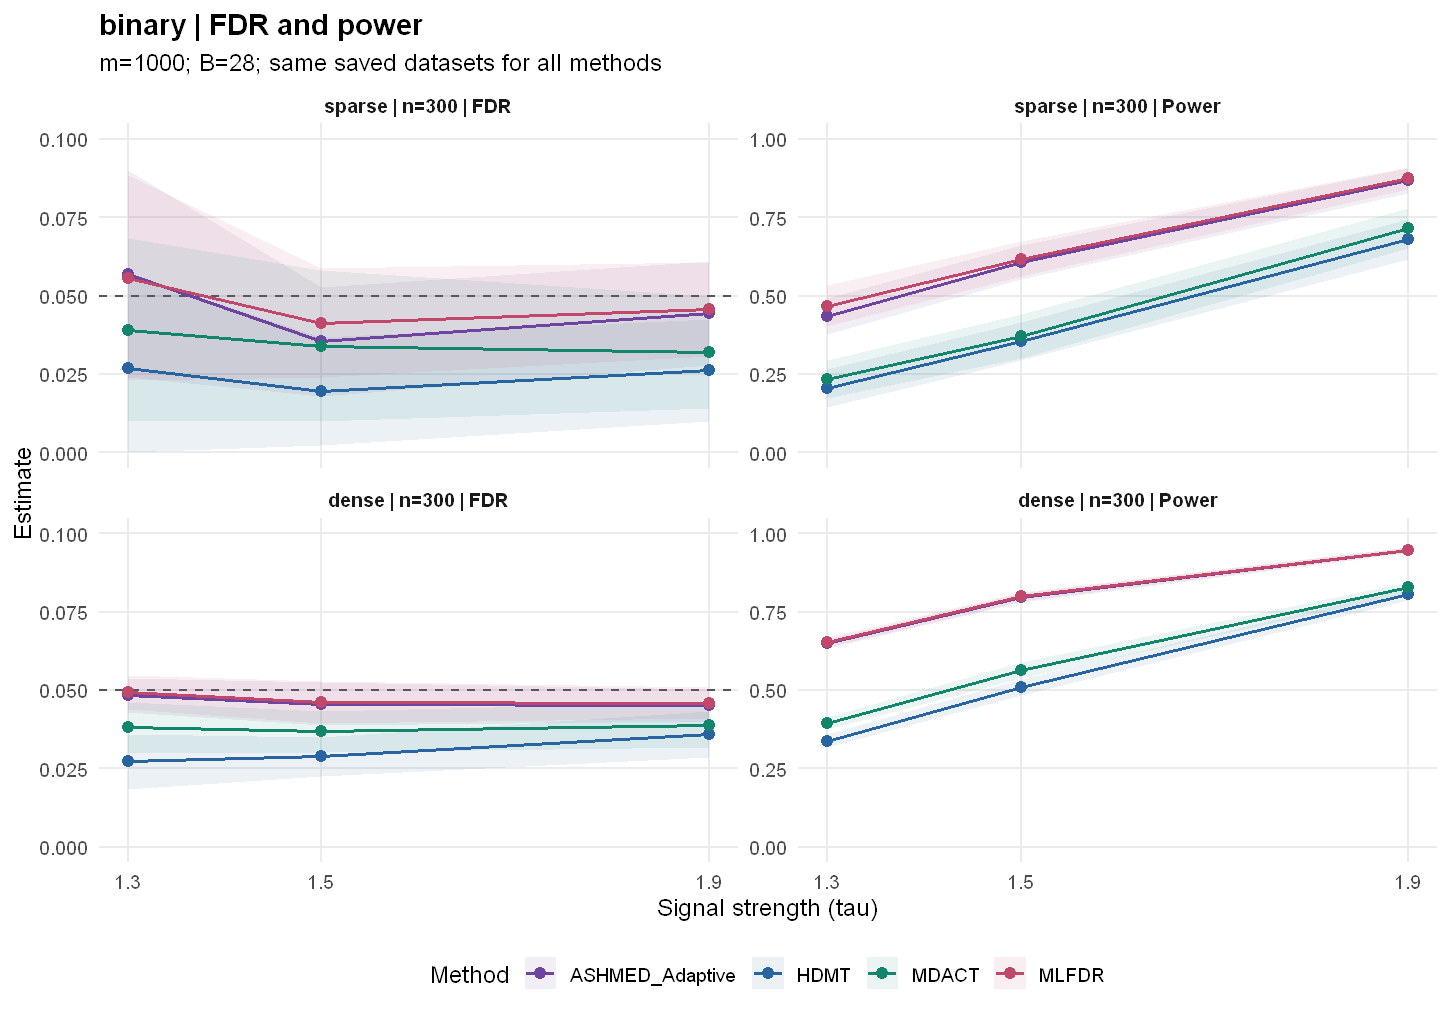

In [9]:
x <- suite[["teaching_fixed"]]
print(plot_adaptive_comparison(x$main,"binary"))
tab <- x$main[x$main$scenario=="binary",c("mixture","tau","method","n_success","n_error",
  "FDR_mean","FDR_mcse","FDR_lo","FDR_hi","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1)); tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

## 相对原版的改进，以及配对比较

原版与改进版在**同一28次重复**上比较；原版此前40次的均值不能直接拿来作这轮配对差。下面展示连续结局的原版/改进版曲线，然后列出 τ=1.5 的所有场景配对差。“改进版−对照”Power为正表示功效提升，FDR为正表示误报增加；应一起解释。单位为百分点，完整配对表保留所有τ。

,scenario,mixture,comparison,n_pairs,delta_FDR_mean,delta_power_mean,delta_power_lo,delta_power_hi
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
7,binary,dense,ASHMED_Adaptive - HDMT,28,1.36,24.44,22.54,26.34
8,confounded,dense,ASHMED_Adaptive - HDMT,28,1.33,25.71,23.69,27.74
9,linear,dense,ASHMED_Adaptive - HDMT,28,2.00,25.31,22.40,28.23
10,binary,sparse,ASHMED_Adaptive - HDMT,28,1.69,22.19,17.83,26.55
11,confounded,sparse,ASHMED_Adaptive - HDMT,28,0.14,22.73,18.24,27.22
12,linear,sparse,ASHMED_Adaptive - HDMT,28,1.76,23.35,17.04,29.65
25,binary,dense,ASHMED_Adaptive - MDACT,28,0.61,19.65,18.19,21.10
26,confounded,dense,ASHMED_Adaptive - MDACT,28,0.66,21.38,19.36,23.39
27,linear,dense,ASHMED_Adaptive - MDACT,28,1.09,21.01,18.75,23.28



 paper_adjusted 


,scenario,mixture,comparison,n_pairs,delta_FDR_mean,delta_power_mean,delta_power_lo,delta_power_hi
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
7,binary,dense,ASHMED_Adaptive - HDMT,28,1.67,28.54,26.44,30.64
8,confounded,dense,ASHMED_Adaptive - HDMT,28,1.38,29.39,27.68,31.10
9,linear,dense,ASHMED_Adaptive - HDMT,28,1.57,26.95,24.68,29.21
10,binary,sparse,ASHMED_Adaptive - HDMT,28,1.60,25.18,20.62,29.73
11,confounded,sparse,ASHMED_Adaptive - HDMT,28,0.63,25.00,20.62,29.38
12,linear,sparse,ASHMED_Adaptive - HDMT,28,1.70,29.82,23.72,35.92
25,binary,dense,ASHMED_Adaptive - MDACT,28,0.87,23.11,21.07,25.14
26,confounded,dense,ASHMED_Adaptive - MDACT,28,0.66,24.05,22.29,25.82
27,linear,dense,ASHMED_Adaptive - MDACT,28,1.04,22.04,19.79,24.28


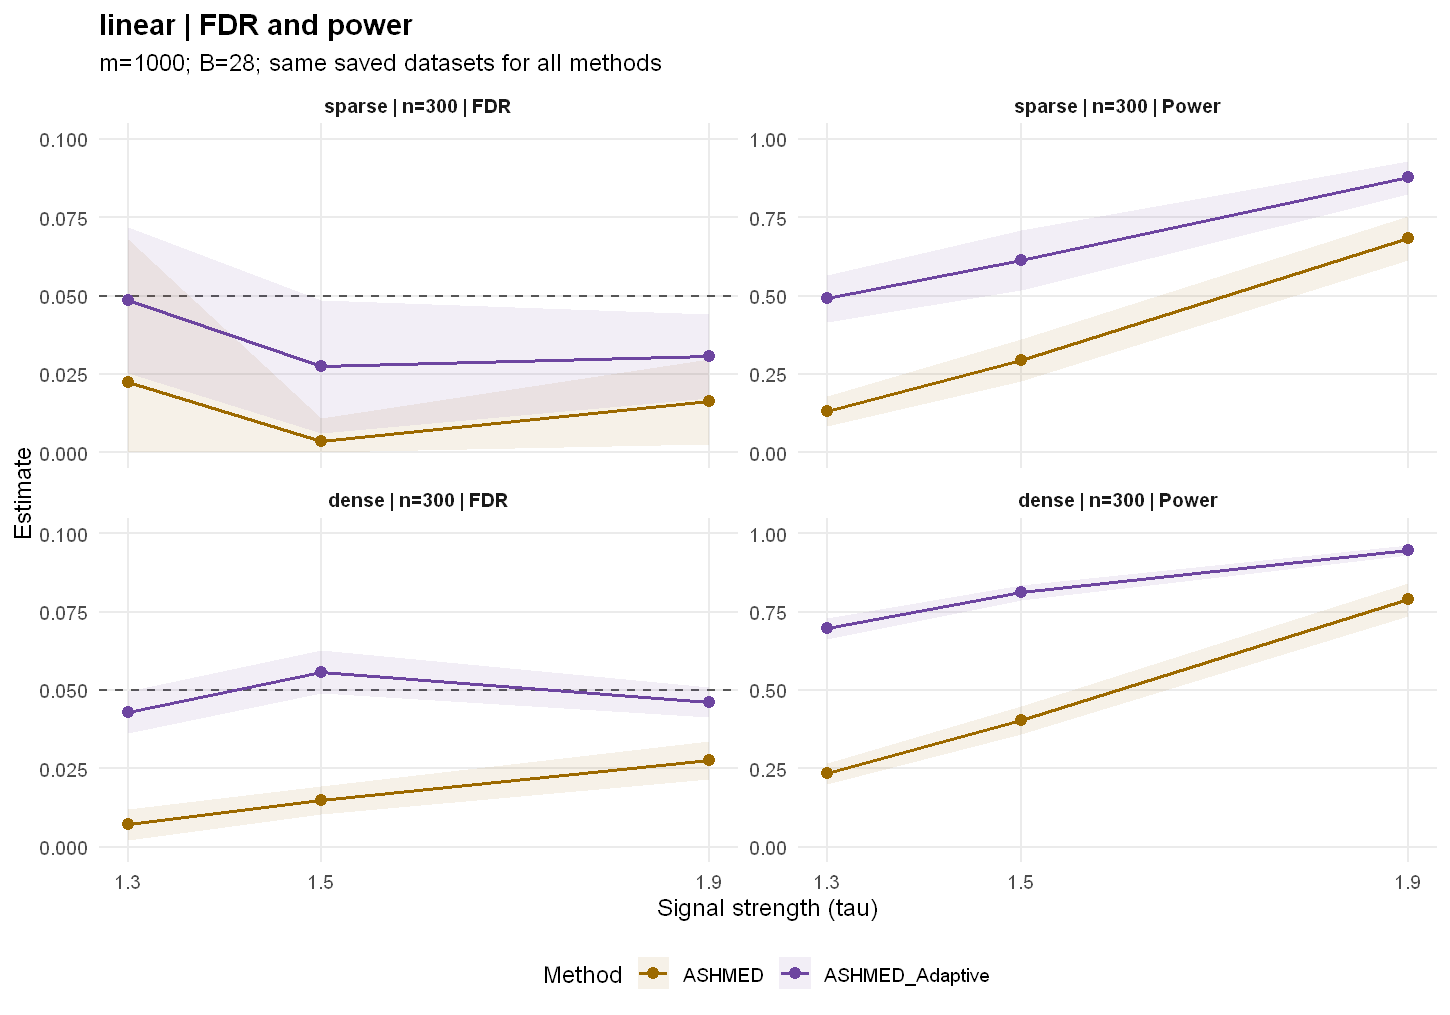


 teaching_fixed 


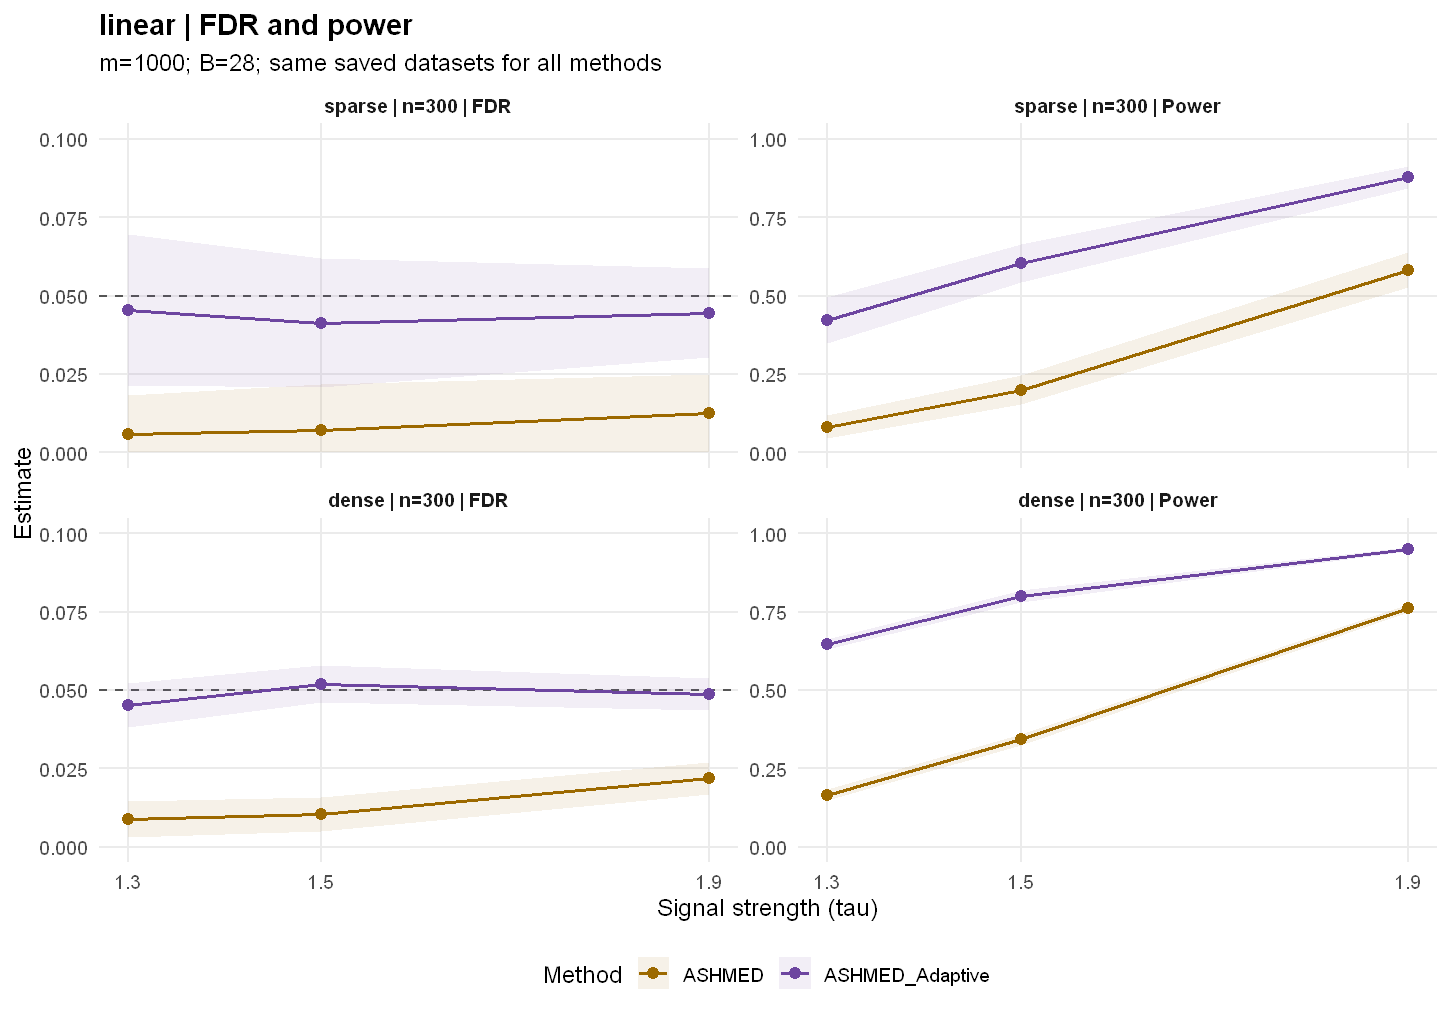

In [10]:
for (name in names(suite)) {
  x <- suite[[name]]
  original <- x$summary[x$summary$method %in% c("ASHMED","ASHMED_Adaptive"),]
  print(plot_adaptive_comparison(original,"linear"))
  tab <- x$paired[x$paired$tau==1.5,c("scenario","mixture","comparison","n_pairs",
    "delta_FDR_mean","delta_power_mean","delta_power_lo","delta_power_hi")]
  for (key in c("delta_FDR_mean","delta_power_mean","delta_power_lo","delta_power_hi"))
    tab[[key]] <- round(100*tab[[key]],2)
  cat("\n",name,"\n"); IRdisplay::display(tab)
}

## 检查优化和FDR校准

固定字典的 KKT gap≤1e−4且相对目标变化≤1e−8才标记权重收敛；同时检查边际中心迭代。local FDR的选择均值≤q是算法行为，**不等于实际FDR必然≤q**。下面明确列出FDR均值超过0.05的条件，以及近似区间下界仍超过0.05的更明显偏高条件；不删除这些结果。

In [11]:
for (name in names(suite)) {
  x <- suite[[name]]; f <- x$fits
  cat("\n",name,"拟合诊断\n")
  IRdisplay::display(data.frame(fits=nrow(f),weight_converged=sum(f$converged),
    location_converged=sum(f$location_converged),fallbacks=sum(f$fallback),
    max_gap=max(f$dual_gap),max_selected_lfdr=max(f$selected_mean_lfdr,na.rm=TRUE)))
  s <- x$main; s$clear_excess <- s$FDR_lo>.05
  IRdisplay::display(s[s$FDR_mean>.05,c("scenario","mixture","tau","method",
    "FDR_mean","FDR_lo","FDR_hi","clear_excess","power_mean")])
}

fits,weight_converged,location_converged,fallbacks,max_gap,max_selected_lfdr
<int>,<int>,<int>,<int>,<dbl>,<dbl>
504,504,504,1,9.98783e-05,0.04999155


,scenario,mixture,tau,method,FDR_mean,FDR_lo,FDR_hi,clear_excess,power_mean
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
32,confounded,dense,1.3,ASHMED_Adaptive,0.05437201,0.04833200,0.06041202,FALSE,0.7030124
35,confounded,dense,1.3,MLFDR,0.05490509,0.04852541,0.06128477,FALSE,0.7065377
42,confounded,dense,1.9,ASHMED_Adaptive,0.05049919,0.04603844,0.05495995,FALSE,0.9425956
45,confounded,dense,1.9,MLFDR,0.05059000,0.04600162,0.05517838,FALSE,0.9441456
47,confounded,sparse,1.3,ASHMED_Adaptive,0.08270648,0.02910756,0.13630540,FALSE,0.4384061
48,confounded,sparse,1.3,HDMT,0.06261467,0.02178440,0.10344494,FALSE,0.2205899
49,confounded,sparse,1.3,MDACT,0.07222222,0.00000000,0.14932514,FALSE,0.2383729
50,confounded,sparse,1.3,MLFDR,0.08074078,0.03060404,0.13087752,FALSE,0.4412620
58,confounded,sparse,1.9,HDMT,0.07398402,0.04354836,0.10441968,FALSE,0.7494257


fits,weight_converged,location_converged,fallbacks,max_gap,max_selected_lfdr
<int>,<int>,<int>,<int>,<dbl>,<dbl>
504,504,504,0,9.99334e-05,0.04999945


,scenario,mixture,tau,method,FDR_mean,FDR_lo,FDR_hi,clear_excess,power_mean
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
17,binary,sparse,1.3,ASHMED_Adaptive,0.05695852,0.02394394,0.08997309,FALSE,0.4339286
20,binary,sparse,1.3,MLFDR,0.05564138,0.02296421,0.08831855,FALSE,0.4678571
40,confounded,dense,1.5,MLFDR,0.05052159,0.04371234,0.05733084,FALSE,0.8092857
42,confounded,dense,1.9,ASHMED_Adaptive,0.05175350,0.04616642,0.05734059,FALSE,0.9439286
45,confounded,dense,1.9,MLFDR,0.05241713,0.04673640,0.05809785,FALSE,0.9442857
50,confounded,sparse,1.3,MLFDR,0.05309343,0.01887933,0.08730754,FALSE,0.4160714
52,confounded,sparse,1.5,ASHMED_Adaptive,0.05911540,0.02966354,0.08856727,FALSE,0.6250000
53,confounded,sparse,1.5,HDMT,0.05283615,0.02551311,0.08015920,FALSE,0.3750000
54,confounded,sparse,1.5,MDACT,0.06478032,0.03128252,0.09827813,FALSE,0.4250000



 paper_adjusted 拟合诊断

 teaching_fixed 拟合诊断


## 一次拟合长什么样

预先取两套中“线性、密集、τ=1.5、第13次”作示例。均值和尺度只从估计系数学习；真值在拟合之后才加入此表。第一套β多为负、第二套β为正，改进版应由数据识别方向，而无需配置真实方向。总计64成分（其中H11为49成分）的字典完整权重、优化轨迹和1000条后验均有CSV。

后验采用非零中心正态共轭公式，产品均值包括分量内αβ协方差，产品SD包括混合不确定性。它们是经验贝叶斯插件后验矩，未包含超参数估计不确定性；不把均值±1.96SD当作精确可信区间。

In [12]:
for (name in names(suite)) {
  x <- suite[[name]]; p <- x$example$posterior; d <- x$example$result$diagnostics
  cat("\n",name,"：",x$example$case_id,"\n")
  IRdisplay::display(data.frame(link=c("alpha","beta"),
    learned_mean=c(d$locations$alpha$mean,d$locations$beta$mean),
    fitted_alt_fraction=c(d$locations$alpha$pi1,d$locations$beta$pi1)))
  IRdisplay::display(data.frame(state=names(d$pi),fitted_pi=unname(d$pi)))
  IRdisplay::display(head(p[order(p$lfdr),c("pathway_id","truth_state","H00","H10","H01","H11",
    "lfdr","reject","alpha_hat","alpha_mean","beta_hat","beta_mean","mediation_mean","mediation_sd")],10))
}

link,learned_mean,fitted_alt_fraction
<chr>,<dbl>,<dbl>
alpha,0.5268754,0.3867425
beta,-0.7473629,0.4160068


state,fitted_pi
<chr>,<dbl>
H00,0.4028921
H10,0.1819159
H01,0.2109856
H11,0.2042064


,pathway_id,truth_state,H00,H10,H01,H11,lfdr,reject,alpha_hat,alpha_mean,beta_hat,beta_mean,mediation_mean,mediation_sd
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pathway_0101,pathway_0101,H11,9.069364e-36,9.822257e-32,5.016249e-05,0.9999498,5.016249e-05,TRUE,0.9557390,0.5268699,-0.7120236,-0.7193580,-0.3790081,0.02793198
pathway_0659,pathway_0659,H11,3.002047e-61,2.861228e-57,5.781464e-05,0.9999422,5.781464e-05,TRUE,0.9956641,0.5268666,-0.9552692,-0.9127064,-0.4808745,0.02786877
pathway_0127,pathway_0127,H11,4.128643e-45,3.661828e-41,6.247198e-05,0.9999375,6.247198e-05,TRUE,1.0143865,0.5268644,-0.8086023,-0.7959865,-0.4193769,0.02790336
pathway_0727,pathway_0727,H11,2.120178e-26,9.389410e-23,1.157281e-04,0.9998843,1.157281e-04,TRUE,0.8859836,0.5268315,-0.6470424,-0.6703222,-0.3531468,0.02963477
pathway_0528,pathway_0528,H11,2.818567e-47,1.139534e-43,1.317835e-04,0.9998682,1.317835e-04,TRUE,0.9871893,0.5268252,-0.8159925,-0.8023137,-0.4226791,0.02767871
pathway_0148,pathway_0148,H11,1.853410e-31,5.681548e-28,1.680290e-04,0.9998320,1.680290e-04,TRUE,0.9202757,0.5268040,-0.6493447,-0.6687364,-0.3522930,0.02752059
pathway_0701,pathway_0701,H11,3.100330e-54,7.012455e-51,2.227595e-04,0.9997772,2.227595e-04,TRUE,0.8820106,0.5267736,-0.9651419,-0.9154293,-0.4822240,0.03003649
pathway_0382,pathway_0382,H11,3.145425e-25,6.337667e-22,2.427075e-04,0.9997573,2.427075e-04,TRUE,0.8122677,0.5267611,-0.6350011,-0.6610653,-0.3482235,0.02987744
pathway_0081,pathway_0081,H11,2.564897e-51,4.653101e-48,2.771020e-04,0.9997229,2.771020e-04,TRUE,0.8888612,0.5267447,-0.7844684,-0.7780519,-0.4098347,0.02628035


link,learned_mean,fitted_alt_fraction
<chr>,<dbl>,<dbl>
alpha,0.2950709,0.4043834
beta,0.7494170,0.4000000


state,fitted_pi
<chr>,<dbl>
H00,0.3872149
H10,0.2134451
H01,0.2042289
H11,0.1951111


,pathway_id,truth_state,H00,H10,H01,H11,lfdr,reject,alpha_hat,alpha_mean,beta_hat,beta_mean,mediation_mean,mediation_sd
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pathway_0941,pathway_0941,H11,3.563865e-36,5.686016e-32,5.501562e-05,0.9999450,5.501562e-05,TRUE,0.5564103,0.2954446,0.7136105,0.7475208,0.2208406,0.005431559
pathway_0296,pathway_0296,H11,2.867412e-52,1.697183e-48,1.025068e-04,0.9998975,1.025068e-04,TRUE,0.5105621,0.2966711,0.8800946,0.7658659,0.2273537,0.016935253
pathway_0513,pathway_0513,H11,6.939038e-23,7.626187e-20,4.667272e-04,0.9995333,4.667272e-04,TRUE,0.4533444,0.2961996,0.6049345,0.7313087,0.2164920,0.013252158
pathway_0999,pathway_0999,H11,8.004840e-40,9.987911e-37,5.318766e-04,0.9994681,5.318766e-04,TRUE,0.4923607,0.2951449,0.7191770,0.7477617,0.2206925,0.007033320
pathway_0364,pathway_0364,H11,5.229646e-40,6.293629e-37,5.543098e-04,0.9994457,5.543098e-04,TRUE,0.4968450,0.2951408,0.7183746,0.7477054,0.2206725,0.007112209
pathway_0645,pathway_0645,H11,3.993962e-34,3.684562e-31,6.584190e-04,0.9993416,6.584190e-04,TRUE,0.4493110,0.2951310,0.6930353,0.7462585,0.2202328,0.007743904
pathway_0919,pathway_0919,H11,1.170144e-34,1.006923e-31,7.173441e-04,0.9992827,7.173441e-04,TRUE,0.4683890,0.2951548,0.6862205,0.7456361,0.2200633,0.008053742
pathway_0277,pathway_0277,H11,5.812339e-39,3.975168e-36,9.165037e-04,0.9990835,9.165037e-04,TRUE,0.4595605,0.2949805,0.7372052,0.7487982,0.2208790,0.008241536
pathway_0670,pathway_0670,H11,1.147748e-41,7.069175e-39,1.040460e-03,0.9989595,1.040460e-03,TRUE,0.4786886,0.2949501,0.7311284,0.7484279,0.2207460,0.008560124



 paper_adjusted ： linear_dense_n300_t02_r0013 

 teaching_fixed ： linear_dense_n300_t02_r0013 


## 结论与扩展边界

本改进针对这两套**有方向、效应较集中**的数据。一个学习中心无法充分表示多峰或正负混合效应；稀疏弱信号时中心也可能不稳定。二元模型仍使用GLM正态摘要近似。有限条件的经验FDR、内部保留重复和KKT数值收敛都不构成一般FDR控制证明。应结合全部条件及不确定性判断，不能仅凭开发平均Power宣布优势。

最新逐条件结果和解读见 `docs/ASHMED_ADAPTIVE_RUN_REPORT.md`，完整核查见 `docs/ASHMED_ADAPTIVE_VALIDATION.txt`。后续方法仍是 `R/methods/plugins/` 插件；新方法只接收无真值摘要。原版 `ashmed.R` 保持不变，新增实现是 `ashmed_adaptive.R`，调度是 `R/ashmed_optimization.R`。

重跑最终比较：`Rscript --vanilla scripts/run_adaptive_ashmed.R`。重新执行/导出：`python scripts/execute_notebook.py notebooks/04_ashmed_adaptive.ipynb`。开发脚本分别为 `explore_adaptive_ashmed.R` 和 `tune_adaptive_ashmed.R`，会写开发记录及锁定配置；不要在看过最终结果后反复选参数仍把同一13–40次称为保留验证。若改动科学代码，指纹检查会要求重新开发/锁定；应安排新的验证数据或清楚标注探索结果。

## 本轮实际结果解读

固定方案为 **null10（λ=10）**。以下均为第13–40次，每条件28次的结果；开发与确认未混入最终均值。

第一套：论文模型增强信号：原版平均Power 0.461 → 改进版 0.735，提高 **27.4个百分点**；改进版整体FDR 0.0455，逐条件均值范围 0.0274–0.0827。

| 方法 | 整体FDR | 整体Power |
| --- | --- | --- |
| HDMT | 0.0359 | 0.5255 |
| MDACT | 0.0394 | 0.5628 |
| MLFDR | 0.0469 | 0.7402 |
| ASHMED | 0.0230 | 0.4610 |
| ASHMED_Adaptive | 0.0455 | 0.7347 |

最高FDR出现在 confounded / sparse / τ=1.3：均值0.0827，MCSE=0.0261，近似95%区间[0.0291, 0.1363]。该条件需保留，不能据整体平均删除或忽略。

改进版没有条件的近似FDR区间下界超过0.05；部分点估计高于q，应保留不确定性。区间包含q不等于已证明控制。

第二套：固定效应教学数据：原版平均Power 0.397 → 改进版 0.715，提高 **31.8个百分点**；改进版整体FDR 0.0466，逐条件均值范围 0.0348–0.0591。

| 方法 | 整体FDR | 整体Power |
| --- | --- | --- |
| HDMT | 0.0353 | 0.4818 |
| MDACT | 0.0438 | 0.5187 |
| MLFDR | 0.0486 | 0.7253 |
| ASHMED | 0.0204 | 0.3970 |
| ASHMED_Adaptive | 0.0466 | 0.7148 |

最高FDR出现在 confounded / sparse / τ=1.5：均值0.0591，MCSE=0.0144，近似95%区间[0.0297, 0.0886]。该条件需保留，不能据整体平均删除或忽略。

改进版没有条件的近似FDR区间下界超过0.05；部分点估计高于q，应保留不确定性。区间包含q不等于已证明控制。

改进版明显提高当前两套数据的识别效率，但没有在所有条件超过MLFDR。优势与有方向、集中效应的建模匹配有关，混合方向等场景需要新测试；全部失败尝试和校准限制保留。更详细解读、逐条件表及核查见 `docs/ASHMED_ADAPTIVE_RUN_REPORT.md`。